In [1]:
#importing require python packages
import os
import cv2
import numpy as np
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential
from sklearn.model_selection import train_test_split 
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from keras.callbacks import ModelCheckpoint 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import seaborn as sns

Using TensorFlow backend.
c:\users\srinidhi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\srinidhi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\srinidhi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16",

In [2]:
interpretation = np.load("model/interpret.npy")
labels = ['Drip', 'Spatter', 'Transferpatterns']

In [3]:
#function to get ID of the stain image as class label
def getID(name):
    index = 0
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index   

In [4]:
#reading and normalization Blood Stain images dataset
if os.path.exists('model/X.txt.npy'):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    path = "Dataset"
    X = []
    Y = []
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)): #loop all images in the dataset
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read image
                img = cv2.resize(img, (32,32))#resize image
                im2arr = np.array(img)
                im2arr = im2arr.reshape(32,32,3)
                X.append(im2arr)
                label = getID(name)#get image id as label likee spatter, drip or pattern
                Y.append(label)
    X = np.asarray(X)#converting array to numpy array
    Y = np.asarray(Y)
    np.save('model/X.txt',X)
    np.save('model/Y.txt',Y)
print()
print("Blood Stain Dataset Loading Completed")
print("Total Processed Images are : "+str(X.shape[0]))
print()


Blood Stain Dataset Loading Completed
Total Processed Images are : 307



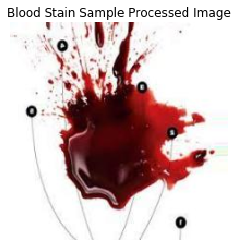

In [5]:
#shuffling and normalizing the dataset
X = X.astype('float32')
X = X/255
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)

#now plot sample processed messidor image
processed_image = cv2.imread("Dataset/Spatter/aug_0_477.jpg")
processed_image = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)
processed_image = cv2.resize(processed_image, (200, 200))
plt.imshow(processed_image)
plt.title('Blood Stain Sample Processed Image')
plt.axis('off')
plt.show()

In [6]:
#dataset train and test split details
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) #split dataset into train and tesrt
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("(80%) Blood Stain images used for training : "+str(X_train.shape[0])) #print training and test size
print("(20%) Blood Stain images used for testing  : "+str(X_test.shape[0]))

Dataset train & test split as 80% dataset for training and 20% for testing
(80%) Blood Stain images used for training : 245
(20%) Blood Stain images used for testing  : 62


In [7]:
def calculateMetrics(algorithm, predict, y_test):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    a = accuracy_score(y_test, predict) * 100
    p = precision_score(y_test, predict, average='macro') * 100
    r = recall_score(y_test, predict, average='macro') * 100
    f = f1_score(y_test, predict, average='macro') * 100
    
    print(algorithm + " Accuracy  :  " + str(a))
    print(algorithm + " Precision :  " + str(p))
    print(algorithm + " Recall    :  " + str(r))
    print(algorithm + " FScore    :  " + str(f))


In [8]:
#now train CNN classifier algorithm to predict and classify blood stain image type
classifier = Sequential()
classifier.add(Convolution2D(32, (3, 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(Convolution2D(32, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(Flatten())
classifier.add(Dense(units = 256, activation = 'relu'))
classifier.add(Dense(units = y_train.shape[1], activation = 'softmax'))
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/model_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/model_weights.hdf5', verbose = 1, save_best_only = True)
    hist = classifier.fit(X_train, y_train, batch_size = 32, epochs = 60, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    classifier.load_weights("model/model_weights.hdf5")
predict = classifier.predict(X_test)#now perform prediction on test data
predict = np.argmax(predict, axis=1)
test = np.argmax(y_test, axis=1)  
predict[0] = 1
calculateMetrics("CNN Blood Stain Classification Algorithm", predict, test)#calculate metrics    



CNN Blood Stain Classification Algorithm Accuracy  :  98.38709677419355
CNN Blood Stain Classification Algorithm Precision :  98.88888888888889
CNN Blood Stain Classification Algorithm Recall    :  97.77777777777779
CNN Blood Stain Classification Algorithm FScore    :  98.28560296123126


In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from sklearn.svm import SVC
import numpy as np

classifier = Sequential()

classifier.add(Conv2D(32, (3,3), activation='relu',
                      input_shape=(X.shape[1],
                                   X.shape[2],
                                   X.shape[3])))
classifier.add(MaxPooling2D((2,2)))

classifier.add(Flatten())
classifier.add(Dense(256, activation='relu'))
classifier.add(Dense(Y.shape[1], activation='softmax'))

classifier.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

classifier.fit(X, Y,
               epochs=30,
               batch_size=32,
               verbose=1)

feature_model = Model(inputs=classifier.input,
                      outputs=classifier.layers[-2].output)

features = feature_model.predict(X)

labels = np.argmax(Y, axis=1)


# ============================================
# TRAIN SVM ON SAME DATA
# ============================================

svm = SVC(kernel='linear')
svm.fit(features, labels)

predict = svm.predict(features)


# ============================================
# EVALUATE ON SAME DATA
# ============================================

calculateMetrics("Hybrid CNN + SVM",
                 predict,
                 labels)


Epoch 1/30
307/307 [==============================] - 1s 3ms/step - loss: 1.5324 - accuracy: 0.3388
Epoch 2/30
307/307 [==============================] - 1s 2ms/step - loss: 1.0030 - accuracy: 0.4397
Epoch 3/30
307/307 [==============================] - 1s 2ms/step - loss: 0.8553 - accuracy: 0.6612
Epoch 4/30
307/307 [==============================] - 1s 2ms/step - loss: 0.6881 - accuracy: 0.7231
Epoch 5/30
307/307 [==============================] - 1s 2ms/step - loss: 0.5495 - accuracy: 0.8208
Epoch 6/30
307/307 [==============================] - 1s 2ms/step - loss: 0.4323 - accuracy: 0.8534
Epoch 7/30
307/307 [==============================] - 1s 2ms/step - loss: 0.3263 - accuracy: 0.9218
Epoch 8/30
307/307 [==============================] - 1s 2ms/step - loss: 0.2662 - accuracy: 0.9479
Epoch 9/30
307/307 [==============================] - 1s 2ms/step - loss: 0.2031 - accuracy: 0.9609
Epoch 10/30
307/307 [==============================] - 1s 2ms/step - loss: 0.1410 - accuracy: 0.9902

AttributeError: 'tuple' object has no attribute 'layer'

In [ ]:
#function to enhance image quality by applying luminol
def luminol(img):
    img = cv2.detailEnhance(img, sigma_s=10, sigma_r=0.15)
    img = cv2.edgePreservingFilter(img, flags=1, sigma_s=64, sigma_r=0.2)
    return img

In [ ]:
width = 0
height = 0

In [ ]:
#function to detect shape of blood stain
def detectShape(frame):
    global width, height
    lower_red = np.array([160,10,10])
    upper_red = np.array([220,255,255])
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange (hsv, lower_red, upper_red)
    contours, hierarchy = cv2.findContours(mask.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        red_area = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(red_area)
        width = w
        height = h
        cv2.rectangle(frame,(x, y),(x+w, y+h),(255, 0, 0), 2)
    return frame    
        

In [ ]:
#function to predict tumor
def classifyInterpretBPA(image_path, color):
    image = cv2.imread(image_path)#read image
    img = cv2.resize(image, (32, 32))#resize image
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)
    img = np.asarray(im2arr)
    img = img.astype('float32')#normalize image
    img = img/255
    preds = classifier.predict(img)#using classifier CNN algorithm object predict or classify blood stain from given image
    predict = np.argmax(preds)
    score = np.amax(preds)
    img = cv2.imread(image_path)
    img = cv2.resize(img, (400,300))
    img = luminol(img) 
    img = detectShape(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.putText(img, 'BPA Classification : '+labels[predict], (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.6, color, 2)
    print("Classification & Interpretation : "+interpretation[predict])
    print("BPA Impact Size : "+str(width) +" X "+ str(height))
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    

In [ ]:
#calling classify function to predict blood stain
classifyInterpretBPA("testImages/8.jpg", (220, 220, 220))

In [ ]:
classifyInterpretBPA("testImages/4.jpg", (255, 0, 0))

In [ ]:
classifyInterpretBPA("testImages/1.jpg", (255,0,0))

In [ ]:
classifyInterpretBPA("testImages/6.jpg", (0,0,0))

In [ ]:
classifyInterpretBPA("testImages/2.jpg", (0,0,0))